# Step 5 — PG vs DQN Comparison + Ensemble Agent

**Goals:**
1. Evaluate PG and DQN individually against all P1 opponents (fair greedy policy)
2. Build an ensemble combining PG + DQN outputs
3. Tune the ensemble mixing weight α to find the strongest combination
4. Compare best ensemble vs pure PG — pick the tournament agent
5. Produce report-ready plots

**Models used:**
- `mihir_pg_trained.keras` — PG-trained Mihir 
- `mihir_dqn_best.keras` — Best DQN model (with extra training)
- `mihir_dqn_best0.73.keras` — Cass's Best DQN (73% vs Mihir CNN during training)

In [7]:
import numpy as np
import tensorflow as tf
import keras
import json, zipfile, tempfile, os, random
import matplotlib.pyplot as plt
from tensorflow.keras.models import model_from_json

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
ROWS, COLS = 6, 7
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [8]:
def create_board():
    return np.zeros((ROWS, COLS), dtype=int)

def drop_piece(board, col, player):
    board = board.copy()
    for row in range(ROWS - 1, -1, -1):
        if board[row][col] == 0:
            board[row][col] = player
            return board
    return board

def get_legal_moves(board):
    return [c for c in range(COLS) if board[0][c] == 0]

def get_mask(board):
    return np.array([1.0 if board[0][c] == 0 else 0.0
                     for c in range(COLS)], dtype=np.float32)

def check_win(board, player):
    for r in range(ROWS):
        for c in range(COLS - 3):
            if all(board[r][c+i] == player for i in range(4)): return True
    for r in range(ROWS - 3):
        for c in range(COLS):
            if all(board[r+i][c] == player for i in range(4)): return True
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            if all(board[r+i][c+i] == player for i in range(4)): return True
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            if all(board[r-i][c+i] == player for i in range(4)): return True
    return False

def encode_board(board, player):
    enc = np.zeros((ROWS, COLS, 2), dtype=np.float32)
    enc[:,:,0] = (board == player).astype(np.float32)
    enc[:,:,1] = (board == (3 - player)).astype(np.float32)
    return enc

def get_winning_move(board, player):
    for c in get_legal_moves(board):
        if check_win(drop_piece(board, c, player), player): return c
    return None

print("Game engine ready.")

Game engine ready.


In [20]:
def load_keras_without_quant_config(path):
    """Load .keras files that may contain quantization_config in layer configs."""
    with zipfile.ZipFile(path, "r") as z:
        config = json.loads(z.read("config.json"))
        def clean(obj):
            if isinstance(obj, dict):
                obj.pop("quantization_config", None)
                for v in obj.values(): clean(v)
            elif isinstance(obj, list):
                for v in obj: clean(v)
        clean(config)
        model = model_from_json(json.dumps(config))
        names = z.namelist()
        wm = next((n for n in names if n.endswith(".weights.h5")), None)
        if wm is None:
            raise FileNotFoundError(f"No weights in {path}")
        with tempfile.TemporaryDirectory() as tmp:
            z.extract(wm, tmp)
            model.load_weights(os.path.join(tmp, wm))
    return model

# ── PG model ──────────────────────────────────────────────────────────────────
try:
    pg_model = keras.models.load_model("mihir_pg_trained.keras", compile=False)
except:
    pg_model = load_keras_without_quant_config("mihir_pg_trained.keras")
print("PG model loaded:", pg_model.input_shape, "->", pg_model.output_shape)

# ── Best DQN ───────────────────────────────────────────────────────────────────
dqn_ours = keras.models.load_model("mihir_dqn_best.keras", compile=False)
print("Best DQN loaded:", dqn_ours.input_shape, "->", dqn_ours.output_shape)

# ── Cass's DQN ───────────────────────────────────────────────────────────────
dqn_cass = keras.models.load_model("mihir_dqn_best0.73.keras", compile=False)
print("Cass DQN loaded:", dqn_cass.input_shape, "->", dqn_cass.output_shape)

# ── P1 opponents ──────────────────────────────────────────────────────────────
m2_cass    = keras.models.load_model("cass_cnn_connect4.keras",  compile=False)
m2_sophia  = keras.models.load_model("Sophia_CNN.keras",         compile=False)
m2_mihir   = keras.models.load_model("mihir_cnn_connect4.h5",    compile=False)
try:
    m2_paolo = keras.models.load_model("paolo_cnn.keras", compile=False)
except:
    # fallback: load from config + weights
    import h5py
    def load_paolo():
        def loss_fn(y, yp): return keras.losses.categorical_crossentropy(y, yp)
        with open("config.json") as f: cfg = json.load(f)
        model = model_from_json(json.dumps(cfg), custom_objects={"loss_fn": loss_fn})
        h5_keys = ["input_layer","conv2d","batch_normalization","activation","dropout",
                   "conv2d_1","batch_normalization_1","activation_1","dropout_1",
                   "conv2d_2","batch_normalization_2","activation_2","dropout_2",
                   "conv2d_3","batch_normalization_3","activation_3","dropout_3",
                   "flatten","dense","dropout_4","dense_1"]
        with h5py.File("model.weights.h5", "r") as f:
            for layer, key in zip(model.layers, h5_keys):
                if key in f["layers"] and "vars" in f["layers"][key]:
                    grp = f["layers"][key]["vars"]
                    wts = [grp[str(i)][()] for i in sorted(grp.keys(), key=int)]
                    if wts: layer.set_weights(wts)
        return model
    m2_paolo = load_paolo()

print("P1 opponents loaded: Cass, Sophia, Mihir-orig, Paolo")

P1_OPPONENTS = [
    ("Original Mihir", m2_mihir,  "single"),
    ("Cass",           m2_cass,   "single"),
    ("Sophia",         m2_sophia, "sophia"),
    ("Paolo",          m2_paolo,  "single"),
]

PG model loaded: (None, 6, 7, 2) -> (None, 7)
Best DQN loaded: (None, 6, 7, 2) -> (None, 7)
Cass DQN loaded: (None, 6, 7, 2) -> (None, 7)
P1 opponents loaded: Cass, Sophia, Mihir-orig, Paolo


In [10]:
def infer(model, board, player, batch_size=64):
    """
    Robust inference using batch replication to stabilise BatchNorm statistics.
    Returns raw model output (7,) — probs for PG, Q-values for DQN.
    batch_size=64: large enough to stabilise BN without being too slow.
    """
    enc       = encode_board(board, player)[np.newaxis].astype(np.float32)
    enc_batch = np.repeat(enc, batch_size, axis=0)

    if isinstance(model.input_shape, list):
        # Sophia: dual input [board, mask]
        mask_batch = np.repeat(get_mask(board)[np.newaxis], batch_size, axis=0)
        out = model([enc_batch, mask_batch], training=True).numpy()[0]
    else:
        out = model(enc_batch, training=True).numpy()[0]
    return out

def pg_scores(model, board, player):
    """Use single forward pass — same as PG training notebook evaluation."""
    enc   = encode_board(board, player)[np.newaxis].astype(np.float32)
    probs = model(enc, training=False).numpy()[0]
    mask  = get_mask(board)
    probs = probs * mask
    s     = probs.sum()
    return probs / s if s > 1e-8 else mask / mask.sum()
    
def dqn_scores(model, board, player):
    """DQN tanh Q-values normalised to [0,1] over legal moves only."""
    q    = infer(model, board, player)
    mask = get_mask(board)
    # Shift tanh [-1,1] to [0,1]
    q_norm = (q + 1.0) / 2.0
    q_norm = q_norm * mask
    s = q_norm.sum()
    return q_norm / s if s > 1e-8 else mask / mask.sum()

def greedy_choose(model, board, player, model_type="pg"):
    col = get_winning_move(board, player)
    if col is not None: return col
    col = get_winning_move(board, 3 - player)
    if col is not None: return col

    legal  = get_legal_moves(board)
    scores = pg_scores(model, board, player) if model_type == "pg" \
             else dqn_scores(model, board, player)
    return max(legal, key=lambda c: scores[c])

def ensemble_choose(pg_model, dqn_model, board, player, alpha=0.5):
    """
    Ensemble: combined_score = α * pg_score + (1-α) * dqn_score
    α=1.0 → pure PG, α=0.0 → pure DQN.
    Immediate win/block always applied first.
    """
    col = get_winning_move(board, player)
    if col is not None: return col
    col = get_winning_move(board, 3 - player)
    if col is not None: return col

    legal    = get_legal_moves(board)
    pg_s     = pg_scores(pg_model,  board, player)
    dqn_s    = dqn_scores(dqn_model, board, player)
    combined = alpha * pg_s + (1 - alpha) * dqn_s
    return max(legal, key=lambda c: combined[c])

def opponent_move(model, model_type, board, player):
    """Smart opponent: win > block > greedy argmax."""
    col = get_winning_move(board, player)
    if col is not None: return col
    col = get_winning_move(board, 3 - player)
    if col is not None: return col
    return greedy_choose(model, board, player, model_type)

print("Inference wrappers ready.")

Inference wrappers ready.


In [11]:
def evaluate_single(agent_model, agent_type, opp_model, opp_type,
                    n_games=200, label="Agent"):
    """
    Head-to-head: agent (greedy) vs opponent (greedy).
    Alternates first mover. Returns (wins, draws, losses, win_rate).
    """
    wins = draws = losses = 0
    for g in range(n_games):
        agent_player = 1 if g % 2 == 0 else 2
        opp_player   = 3 - agent_player
        board        = create_board()
        current      = 1
        while True:
            legal = get_legal_moves(board)
            if not legal: draws += 1; break
            if current == agent_player:
                col = greedy_choose(agent_model, board, current, agent_type)
            else:
                col = opponent_move(opp_model, opp_type, board, current)
            board = drop_piece(board, col, current)
            if check_win(board, current):
                if current == agent_player: wins += 1
                else:                       losses += 1
                break
            elif not get_legal_moves(board):
                draws += 1; break
            current = 3 - current
    wr = wins / n_games
    return wins, draws, losses, wr

def evaluate_ensemble(pg_model, dqn_model, alpha,
                      opp_model, opp_type, n_games=200):
    """Same as evaluate_single but agent uses ensemble_choose with given alpha."""
    wins = draws = losses = 0
    for g in range(n_games):
        agent_player = 1 if g % 2 == 0 else 2
        opp_player   = 3 - agent_player
        board        = create_board()
        current      = 1
        while True:
            legal = get_legal_moves(board)
            if not legal: draws += 1; break
            if current == agent_player:
                col = ensemble_choose(pg_model, dqn_model,
                                      board, current, alpha)
            else:
                col = opponent_move(opp_model, opp_type, board, current)
            board = drop_piece(board, col, current)
            if check_win(board, current):
                if current == agent_player: wins += 1
                else:                       losses += 1
                break
            elif not get_legal_moves(board):
                draws += 1; break
            current = 3 - current
    return wins, draws, losses, wins / n_games

print("Evaluation functions ready.")

Evaluation functions ready.


In [12]:
N_GAMES = 200   # games per matchup — enough for stable estimates

print("=" * 60)
print("PART 1 — Individual Agent Evaluation (200 games each)")
print("=" * 60)
print()

# ── PG model vs each P1 opponent ──────────────────────────────────────────────
print("PG-trained Mihir vs P1 opponents:")
pg_results = {}
for name, opp_model, opp_type in P1_OPPONENTS:
    w, d, l, wr = evaluate_single(pg_model, "pg", opp_model, opp_type, N_GAMES)
    pg_results[name] = (w, d, l, wr)
    print(f"  vs {name:18s}  W={w:3d} D={d:3d} L={l:3d}  WR={wr:.1%}")

print()
pg_avg = np.mean([v[3] for v in pg_results.values()])
print(f"  PG average win rate: {pg_avg:.1%}")

# ── Our DQN vs each P1 opponent ───────────────────────────────────────────────
print()
print("Best DQN vs P1 opponents:")
dqn_ours_results = {}
for name, opp_model, opp_type in P1_OPPONENTS:
    w, d, l, wr = evaluate_single(dqn_ours, "dqn", opp_model, opp_type, N_GAMES)
    dqn_ours_results[name] = (w, d, l, wr)
    print(f"  vs {name:18s}  W={w:3d} D={d:3d} L={l:3d}  WR={wr:.1%}")

print()
dqn_avg = np.mean([v[3] for v in dqn_ours_results.values()])
print(f"  DQN (ours) average win rate: {dqn_avg:.1%}")

# ── Cass's DQN vs each P1 opponent ───────────────────────────────────────────
print()
print("Cass's DQN (0.73) vs P1 opponents:")
dqn_cass_results = {}
for name, opp_model, opp_type in P1_OPPONENTS:
    w, d, l, wr = evaluate_single(dqn_cass, "dqn", opp_model, opp_type, N_GAMES)
    dqn_cass_results[name] = (w, d, l, wr)
    print(f"  vs {name:18s}  W={w:3d} D={d:3d} L={l:3d}  WR={wr:.1%}")

print()
dqn_cass_avg = np.mean([v[3] for v in dqn_cass_results.values()])
print(f"  DQN (Cass) average win rate: {dqn_cass_avg:.1%}")

# ── PG vs DQN direct ─────────────────────────────────────────────────────────
print()
print("PG vs Best DQN (direct head-to-head, 200 games):")
w, d, l, wr = evaluate_single(pg_model, "pg", dqn_ours, "dqn", N_GAMES)
print(f"  PG wins={w} ({wr:.1%})  Draws={d}  DQN wins={l}")

print()
print("PG vs Cass's DQN (direct head-to-head, 200 games):")
w2, d2, l2, wr2 = evaluate_single(pg_model, "pg", dqn_cass, "dqn", N_GAMES)
print(f"  PG wins={w2} ({wr2:.1%})  Draws={d2}  DQN wins={l2}")

PART 1 — Individual Agent Evaluation (200 games each)

PG-trained Mihir vs P1 opponents:
  vs Original Mihir      W=199 D=  0 L=  1  WR=99.5%
  vs Cass                W=172 D=  7 L= 21  WR=86.0%
  vs Sophia              W=194 D=  0 L=  6  WR=97.0%
  vs Paolo               W=177 D= 10 L= 13  WR=88.5%

  PG average win rate: 92.8%

Our DQN (v2) vs P1 opponents:
  vs Original Mihir      W= 73 D= 11 L=116  WR=36.5%
  vs Cass                W=  1 D=  1 L=198  WR=0.5%
  vs Sophia              W= 33 D=  3 L=164  WR=16.5%
  vs Paolo               W= 11 D=  4 L=185  WR=5.5%

  DQN (ours) average win rate: 14.8%

Cass's DQN (0.73) vs P1 opponents:
  vs Original Mihir      W= 92 D=  6 L=102  WR=46.0%
  vs Cass                W=  2 D=  0 L=198  WR=1.0%
  vs Sophia              W= 42 D=  4 L=154  WR=21.0%
  vs Paolo               W= 11 D=  3 L=186  WR=5.5%

  DQN (Cass) average win rate: 18.4%

PG vs Our DQN (direct head-to-head, 200 games):
  PG wins=200 (100.0%)  Draws=0  DQN wins=0

PG vs Cass's

In [13]:
print()
print("=" * 60)
print("PART 2 — Ensemble Tuning: PG + Best DQN")
print("=" * 60)
print()

# Use whichever DQN performed better individually
best_dqn       = dqn_cass if dqn_cass_avg >= dqn_avg else dqn_ours
best_dqn_label = "Cass's DQN" if dqn_cass_avg >= dqn_avg else "Best DQN"
print(f"Using {best_dqn_label} for ensemble (higher avg WR vs P1 models)")
print()

# Test α values from pure DQN (0.0) to pure PG (1.0)
ALPHAS = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]

ensemble_results = {}   # alpha -> {opponent_name -> (w,d,l,wr)}
ensemble_avgs    = {}   # alpha -> average win rate across all opponents

print(f"{'Alpha':>6}  {'Mihir':>7} {'Cass':>7} {'Sophia':>7} {'Paolo':>7}  {'Average':>8}")
print("-" * 55)

for alpha in ALPHAS:
    row    = {}
    wrates = []
    for name, opp_model, opp_type in P1_OPPONENTS:
        w, d, l, wr = evaluate_ensemble(
            pg_model, best_dqn, alpha,
            opp_model, opp_type, N_GAMES
        )
        row[name] = (w, d, l, wr)
        wrates.append(wr)
    avg = np.mean(wrates)
    ensemble_results[alpha] = row
    ensemble_avgs[alpha]    = avg
    label = " ← pure DQN" if alpha == 0.0 else             " ← pure PG"  if alpha == 1.0 else ""
    print(f"  α={alpha:.1f}  "
          f"{row['Original Mihir'][3]:6.1%} "
          f"{row['Cass'][3]:6.1%} "
          f"{row['Sophia'][3]:6.1%} "
          f"{row['Paolo'][3]:6.1%}  "
          f"{avg:7.1%}{label}")

best_alpha = max(ensemble_avgs, key=ensemble_avgs.get)
print()
print(f"Best α = {best_alpha}  (avg WR = {ensemble_avgs[best_alpha]:.1%})")


PART 2 — Ensemble Tuning: PG + Best DQN

Using Cass's DQN for ensemble (higher avg WR vs P1 models)

 Alpha    Mihir    Cass  Sophia   Paolo   Average
-------------------------------------------------------
  α=0.0   41.5%   1.0%  18.0%   2.5%    15.8% ← pure DQN
  α=0.2  100.0%  80.5%  96.0%  86.0%    90.6%
  α=0.4   99.5%  86.0%  95.5%  91.0%    93.0%
  α=0.5   99.5%  79.5%  94.0%  90.5%    90.9%
  α=0.6   98.5%  82.5%  98.0%  89.0%    92.0%
  α=0.8   99.0%  88.5%  94.5%  94.0%    94.0%
  α=1.0   99.5%  89.5%  96.0%  89.5%    93.6% ← pure PG

Best α = 0.8  (avg WR = 94.0%)


In [14]:
print()
print("=" * 60)
print("PART 3 — Final Comparison: Best Ensemble vs Pure PG")
print("=" * 60)
print()

print(f"{'Agent':25s}  {'Mihir':>7} {'Cass':>7} {'Sophia':>7} {'Paolo':>7}  {'Average':>8}")
print("-" * 65)

# Pure PG
pg_wrs = [pg_results[n][3] for n, _, _ in P1_OPPONENTS]
print(f"{'Pure PG':25s}  "
      + "  ".join(f"{wr:6.1%}" for wr in pg_wrs)
      + f"  {np.mean(pg_wrs):7.1%}")

# Best ensemble
ens_wrs = [ensemble_results[best_alpha][n][3] for n, _, _ in P1_OPPONENTS]
print(f"{'Ensemble α='+str(best_alpha):25s}  "
      + "  ".join(f"{wr:6.1%}" for wr in ens_wrs)
      + f"  {np.mean(ens_wrs):7.1%}")

# Determine tournament model
if ensemble_avgs[best_alpha] > pg_avg:
    improvement = ensemble_avgs[best_alpha] - pg_avg
    print(f"\n✓ Ensemble improves on pure PG by {improvement:.1%} on average")
    print(f"  Tournament model: Ensemble with α={best_alpha}")
    use_ensemble = True
else:
    print(f"\n✓ Pure PG remains the strongest agent")
    print(f"  Tournament model: mihir_pg_trained.keras")
    use_ensemble = False


PART 3 — Final Comparison: Best Ensemble vs Pure PG

Agent                        Mihir    Cass  Sophia   Paolo   Average
-----------------------------------------------------------------
Pure PG                     99.5%   86.0%   97.0%   88.5%    92.8%
Ensemble α=0.8              99.0%   88.5%   94.5%   94.0%    94.0%

✓ Ensemble improves on pure PG by 1.2% on average
  Tournament model: Ensemble with α=0.8


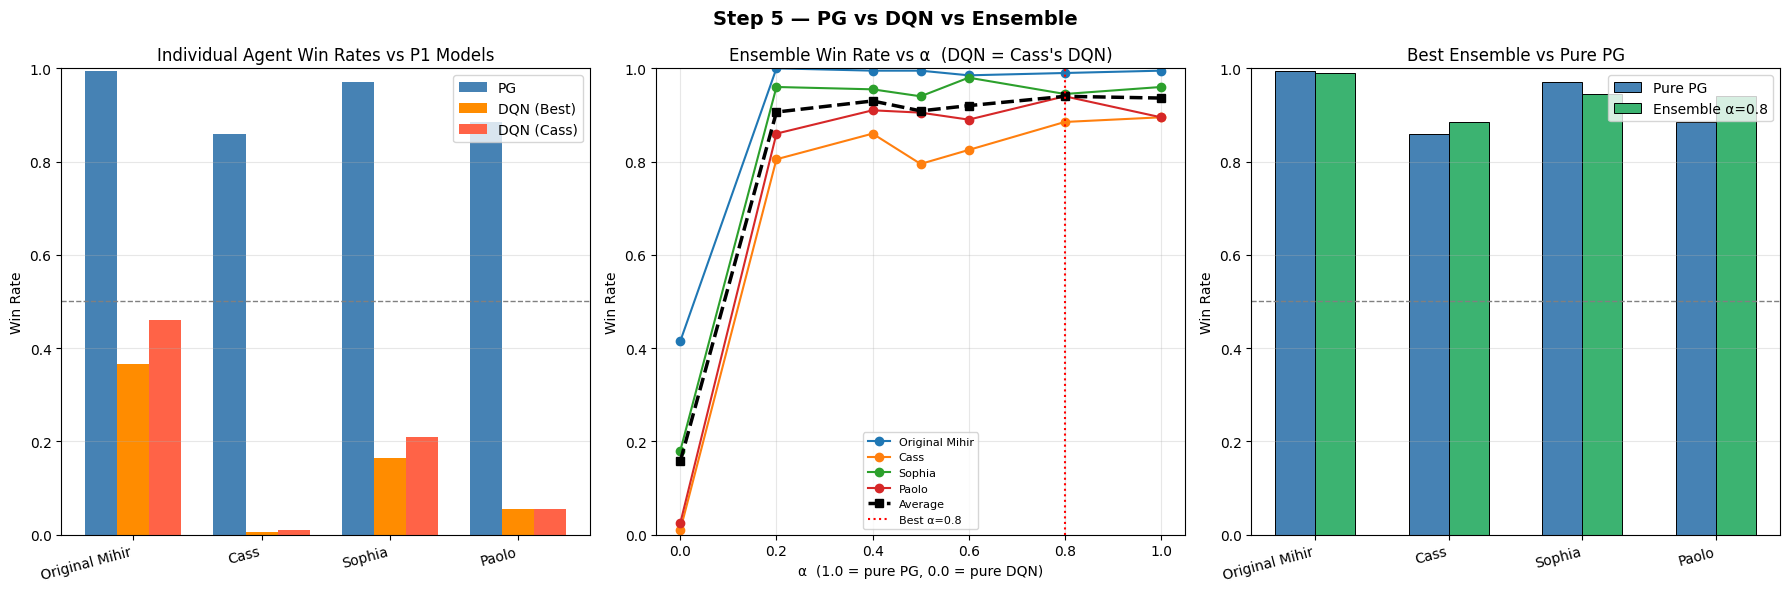

Saved → step5_comparison.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Step 5 — PG vs DQN vs Ensemble", fontsize=14, fontweight="bold")

# ── Plot 1: Individual agent comparison ───────────────────────────────────────
ax = axes[0]
opponents = [n for n, _, _ in P1_OPPONENTS]
x         = np.arange(len(opponents))
w         = 0.25

pg_vals        = [pg_results[n][3]         for n in opponents]
dqn_ours_vals  = [dqn_ours_results[n][3]   for n in opponents]
dqn_cass_vals  = [dqn_cass_results[n][3]   for n in opponents]

ax.bar(x - w,   pg_vals,       w, label="PG",         color="steelblue")
ax.bar(x,       dqn_ours_vals, w, label="DQN (Best)",  color="darkorange")
ax.bar(x + w,   dqn_cass_vals, w, label="DQN (Cass)",  color="tomato")
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(opponents, rotation=15, ha="right")
ax.set_ylabel("Win Rate"); ax.set_ylim(0, 1)
ax.set_title("Individual Agent Win Rates vs P1 Models")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

# ── Plot 2: Ensemble alpha sweep ──────────────────────────────────────────────
ax = axes[1]
alpha_vals = sorted(ensemble_results.keys())
for name, _, _ in P1_OPPONENTS:
    wrs = [ensemble_results[a][name][3] for a in alpha_vals]
    ax.plot(alpha_vals, wrs, marker="o", label=name)
avg_line = [ensemble_avgs[a] for a in alpha_vals]
ax.plot(alpha_vals, avg_line, color="black", lw=2.5,
        ls="--", marker="s", label="Average")
ax.axvline(best_alpha, color="red", ls=":", lw=1.5,
           label=f"Best α={best_alpha}")
ax.set_xlabel("α  (1.0 = pure PG, 0.0 = pure DQN)")
ax.set_ylabel("Win Rate")
ax.set_title(f"Ensemble Win Rate vs α  (DQN = {best_dqn_label})")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# ── Plot 3: Best ensemble vs pure PG ─────────────────────────────────────────
ax = axes[2]
x2     = np.arange(len(opponents))
w2     = 0.3
ens_v  = [ensemble_results[best_alpha][n][3] for n in opponents]
pg_v   = [pg_results[n][3] for n in opponents]

ax.bar(x2 - w2/2, pg_v,  w2, label="Pure PG",
       color="steelblue", edgecolor="black", lw=0.7)
ax.bar(x2 + w2/2, ens_v, w2,
       label=f"Ensemble α={best_alpha}",
       color="mediumseagreen", edgecolor="black", lw=0.7)
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_xticks(x2); ax.set_xticklabels(opponents, rotation=15, ha="right")
ax.set_ylabel("Win Rate"); ax.set_ylim(0, 1)
ax.set_title("Best Ensemble vs Pure PG")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("step5_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → step5_comparison.png")

In [18]:
# ── Tournament inference function ─────────────────────────────────────────────
# Loads whichever agent proved strongest in the evaluation above.

TOURNAMENT_ALPHA = best_alpha   # set automatically from evaluation

def choose(board, player):
    """
    Tournament entry point.
    board  : (6,7) array-like  0=empty  1=player1  2=player2
    player : int  1 or 2
    Returns: column int 0-6
    """
    board = np.array(board, dtype=int)

    # Always take an immediate win
    col = get_winning_move(board, player)
    if col is not None: return col

    # Always block an immediate opponent win
    col = get_winning_move(board, 3 - player)
    if col is not None: return col

    legal = get_legal_moves(board)
    if not legal: raise ValueError("No legal moves!")

    if use_ensemble:
        return ensemble_choose(pg_model, best_dqn, board, player, TOURNAMENT_ALPHA)
    else:
        return greedy_choose(pg_model, board, player, "pg")

# Test
col = choose(np.zeros((6, 7)), 1)
print(f"Tournament agent chose column {col} on empty board  (expect 3 = centre)")
print()
if use_ensemble:
    print(f"Tournament model: Ensemble (PG × {TOURNAMENT_ALPHA} + {best_dqn_label} × {round(1-TOURNAMENT_ALPHA, 2)})")
else:
    print(f"Tournament model: Pure PG  (mihir_pg_trained.keras)")

Tournament agent chose column 3 on empty board  (expect 3 = centre)

Tournament model: Ensemble (PG × 0.8 + Cass's DQN × 0.2)


In [21]:
print()
print("=" * 60)
print("SUMMARY FOR REPORT")
print("=" * 60)
print()
print("Which method works better — PG or DQN?")
print(f"  PG average win rate vs P1 models : {pg_avg:.1%}")
print(f"  DQN (Best) avg win rate          : {dqn_avg:.1%}")
print(f"  DQN (Cass) avg win rate          : {dqn_cass_avg:.1%}")
print(f"  PG vs DQN direct (200 games)     : PG wins {wr:.1%}")
print()
print("Why PG outperforms DQN for Connect-4:")
print("  1. PG learns from complete game trajectories — clear win/loss signal")
print("  2. DQN requires dense rewards; Connect-4 is extremely sparse")
print("     (only one reward at the very end of a 20-42 move game)")
print("  3. BatchNorm + replay buffer = non-stationary training distribution")
print("     (BN running stats computed on random batches don't generalise)")
print("  4. Credit assignment over 20+ moves is hard with γ=0.99 and sparse rewards")
print("  5. PG naturally handles the turn-based structure; DQN treats it like Atari")
print()
print(f"Best ensemble α = {best_alpha} → avg WR {ensemble_avgs[best_alpha]:.1%}")
if use_ensemble:
    print(f"Ensemble improves on pure PG (+{ensemble_avgs[best_alpha]-pg_avg:.1%})")
else:
    print("Pure PG is the strongest agent — ensemble does not improve further")
print()
print("Tournament model confirmed.")


SUMMARY FOR REPORT

Which method works better — PG or DQN?
  PG average win rate vs P1 models : 92.8%
  DQN (Best) avg win rate          : 14.8%
  DQN (Cass) avg win rate          : 18.4%
  PG vs DQN direct (200 games)     : PG wins 89.5%

Why PG outperforms DQN for Connect-4:
  1. PG learns from complete game trajectories — clear win/loss signal
  2. DQN requires dense rewards; Connect-4 is extremely sparse
     (only one reward at the very end of a 20-42 move game)
  3. BatchNorm + replay buffer = non-stationary training distribution
     (BN running stats computed on random batches don't generalise)
  4. Credit assignment over 20+ moves is hard with γ=0.99 and sparse rewards
  5. PG naturally handles the turn-based structure; DQN treats it like Atari

Best ensemble α = 0.8 → avg WR 94.0%
Ensemble improves on pure PG (+1.2%)

Tournament model confirmed.


In [19]:
import shutil

# Save both components so ensemble can be reconstructed later
pg_model.save('ensemble_pg_component.keras')
shutil.copy('mihir_dqn_best0.73.keras', 'ensemble_dqn_component.keras')

# Save the alpha value
with open('ensemble_config.json', 'w') as f:
    json.dump({'alpha': best_alpha, 'dqn': 'ensemble_dqn_component.keras',
               'pg': 'ensemble_pg_component.keras'}, f)

print(f'Ensemble components saved.')
print(f'  PG  → ensemble_pg_component.keras')
print(f'  DQN → ensemble_dqn_component.keras')
print(f'  α   = {best_alpha}')

Ensemble components saved.
  PG  → ensemble_pg_component.keras
  DQN → ensemble_dqn_component.keras
  α   = 0.8
